# Capstone Combined 8-Class Model Comparison — No Data Leakage Version

This Kaggle notebook creates a balanced combined dataset for 8 classes and compares multiple CNN architectures:

- Custom Lightweight CNN
- ResNet18
- MobileNetV3-Small
- EfficientNet-B0
- VGG16

Classes:

1. `anemic`
2. `non_anemic`
3. `benign_leukemia`
4. `early_leukemia`
5. `pre_leukemia`
6. `pro_leukemia`
7. `parasitized`
8. `non_parasitized`

**Updated (accuracy-improvement pass):** class balancing no longer downsamples every class to the smallest one. Small classes are oversampled (duplicated, train split only) and large classes are capped at a much higher number than before, so far more data survives. Split happens BEFORE balancing so no duplicated image can ever leak into another split. A LR scheduler and label smoothing were also added.

**This version:** trains a single fusion model, `MultiNet`, that combines 5 diverse pretrained backbones (`densenet169`, `resnet101d`, `cait_s24_224`, `poolformer_s24`, `visformer_small`) as parallel feature-extraction branches, concatenates their pooled features, and learns a joint classifier head on top -- same fusion pattern as the original `TrueMultiNet`, generalized to these 5 architectures via `timm`. Uses `nn.DataParallel` to spread the model across **2 GPUs** (Kaggle T4 x2).

Important leakage protections:

In [1]:
import os
import random
import shutil
import hashlib
import json
import gc
from pathlib import Path
from collections import defaultdict
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Kaggle folders
BASE_INPUT = Path('/kaggle/input')
WORKING_DIR = Path('/kaggle/working')
DATASET_DIR = WORKING_DIR / 'combined_8class_dataset'
ARTIFACT_DIR = WORKING_DIR / 'model_artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# ---- Balancing strategy ----
# Small classes (e.g. benign_leukemia) are OVERSAMPLED (duplicated, only within
# the train split) up to MAX_TRAIN_PER_CLASS. Large classes (e.g.
# parasitized/anemic) are capped at MAX_TRAIN_PER_CLASS instead of being cut
# down to the smallest class like in the very first version of this notebook.
# Lower this if training is too slow for your Kaggle GPU quota -- the fusion
# MultiNet below is heavier per-image than a single backbone.
MAX_TRAIN_PER_CLASS = 2000
MAX_EVAL_PER_CLASS = 150   # val/test are only capped, NEVER duplicated

IMG_SIZE = 224
# MultiNet runs 5 backbones per forward pass (incl. 2 transformer branches), so
# it needs more memory per sample than a single model. BATCH_SIZE is split
# across both GPUs by DataParallel (e.g. 16 -> 8 samples per GPU). Lower this
# first if you hit CUDA OOM.
BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 5
LR = 1e-4
LABEL_SMOOTHING = 0.05

# Pretrained weights lagbe, Kaggle internet ON rakhben
USE_PRETRAINED = True

# This notebook trains ONLY the fusion MultiNet (5-backbone version).
# Backbones fused inside MultiNet are set in the model-builder cell
# (FUSION_BACKBONES): densenet169, resnet101d, cait_s24_224, poolformer_s24,
# visformer_small -- these are the same 5 models already trained individually
# and ensembled (soft-voting) in the earlier notebook.
MODELS_TO_RUN = [
    'multinet',
]

# Device setup
if torch.cuda.is_available():
    n_gpus = torch.cuda.device_count()
    for i in range(n_gpus):
        print(f'GPU {i}:', torch.cuda.get_device_name(i))
    if n_gpus > 1:
        print(f'{n_gpus} GPUs detected -- MultiNet will be wrapped in nn.DataParallel '
              f'to train across all of them (select "GPU T4 x2" in Kaggle Session Options).')
    else:
        print('Only 1 GPU detected -- training will run on a single GPU (still works, just slower).')
    device = torch.device('cuda')
else:
    n_gpus = 0
    device = torch.device('cpu')

print('Device:', device)
print('Base input:', BASE_INPUT)
print('Working dir:', WORKING_DIR)


GPU 0: Tesla T4
GPU 1: Tesla T4
2 GPUs detected -- MultiNet will be wrapped in nn.DataParallel to train across all of them (select "GPU T4 x2" in Kaggle Session Options).
Device: cuda
Base input: /kaggle/input
Working dir: /kaggle/working


## 2. Check Kaggle Input Datasets

Before running the next cells, add these datasets from Kaggle **Add Input → Datasets**:

- `jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images`
- `mehradaria/leukemia`
- `iarunava/cell-images-for-detecting-malaria`

In [2]:
print("Top-level Kaggle input folders:")
for p in BASE_INPUT.iterdir():
    print("-", p)

print("\nSome nested folders:")
count = 0

for p in BASE_INPUT.rglob("*"):
    if p.is_dir():
        print(p)
        count += 1

        if count >= 80:
            print("... stopped after 80 folders")
            break

Top-level Kaggle input folders:
- /kaggle/input/datasets

Some nested folders:
/kaggle/input/datasets
/kaggle/input/datasets/iarunava
/kaggle/input/datasets/jocelyndumlao
/kaggle/input/datasets/mehradaria
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria
/kaggle/input/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images
/kaggle/input/datasets/mehradaria/leukemia
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Uninfected
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Parasitized
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images/Uninfected
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images/Parasitized
/kaggle/input/datasets/jocelyndumlao/anerbc-anemia-diagnos

In [3]:
# =========================
# 3. Utility functions
# =========================

def collect_images_from_dir(folder_path):
    folder_path = Path(folder_path)
    if not folder_path.exists():
        return []
    return sorted([
        str(p) for p in folder_path.rglob('*')
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])


def collect_images_from_dirs(folder_paths):
    images = []
    for folder in folder_paths:
        images.extend(collect_images_from_dir(folder))
    return sorted(list(set(images)))


def md5_file(path, chunk_size=1024*1024):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def find_dirs_named(name):
    name = name.lower()
    return [p for p in BASE_INPUT.rglob('*') if p.is_dir() and p.name.lower() == name]


def has_child_dirs(parent, child_names):
    parent = Path(parent)
    if not parent.exists():
        return False
    existing = {p.name.lower() for p in parent.iterdir() if p.is_dir()}
    return all(c.lower() in existing for c in child_names)


def choose_dir_with_children(parent_name, child_names, prefer_keywords=None):
    candidates = []
    for p in find_dirs_named(parent_name):
        if has_child_dirs(p, child_names):
            score = sum(len(collect_images_from_dir(p / c)) for c in child_names)
            if prefer_keywords:
                low = str(p).lower()
                for kw in prefer_keywords:
                    if kw.lower() in low:
                        score += 10_000_000
            candidates.append((p, score))
    if not candidates:
        return None
    return sorted(candidates, key=lambda x: x[1], reverse=True)[0][0]


def print_dirs(label, dirs):
    print('' + label)
    for d in dirs:
        print('-', d, '| images:', len(collect_images_from_dir(d)))

## 4. Select Correct Source Folders

This cell avoids the earlier problem where `Uninfected` was mistakenly detected as `infected` because the word **infected** is inside **Uninfected**.

In [4]:
# =========================
# 4. Source folder selection
# =========================

# ---- Malaria: use exact folder names only ----
malaria_parent = choose_dir_with_children('cell_images', ['Parasitized', 'Uninfected'])
if malaria_parent is None:
    raise FileNotFoundError('Could not find malaria cell_images folder with Parasitized and Uninfected.')

parasitized_dirs = [malaria_parent / 'Parasitized']
non_parasitized_dirs = [malaria_parent / 'Uninfected']

# ---- Leukemia: prefer Original folder with Benign, Early, Pre, Pro ----
leukemia_parent = choose_dir_with_children('Original', ['Benign', 'Early', 'Pre', 'Pro'])
if leukemia_parent is None:
    raise FileNotFoundError('Could not find leukemia Original folder with Benign, Early, Pre, Pro.')

benign_dirs = [leukemia_parent / 'Benign']
early_dirs = [leukemia_parent / 'Early']
pre_dirs = [leukemia_parent / 'Pre']
pro_dirs = [leukemia_parent / 'Pro']

# ---- Anemia: use RGB_segmented folders under Anemic_individuals and Healthy_individuals ----
anemic_dirs = []
healthy_dirs = []

for rgb_dir in find_dirs_named('RGB_segmented'):
    low = str(rgb_dir).lower()
    if 'anemic_individuals' in low:
        anemic_dirs.append(rgb_dir)
    elif 'healthy_individuals' in low:
        healthy_dirs.append(rgb_dir)

# Fallback if RGB_segmented is not found
if not anemic_dirs:
    for d in find_dirs_named('Anemic_individuals'):
        anemic_dirs.append(d)
if not healthy_dirs:
    for d in find_dirs_named('Healthy_individuals'):
        healthy_dirs.append(d)

if not anemic_dirs:
    raise FileNotFoundError('Could not find anemia Anemic_individuals/RGB_segmented folders.')
if not healthy_dirs:
    raise FileNotFoundError('Could not find anemia Healthy_individuals/RGB_segmented folders.')

print_dirs('Selected Anemic folders', anemic_dirs)
print_dirs('Selected Non-Anemic / Healthy folders', healthy_dirs)
print_dirs('Selected Leukemia Benign folders', benign_dirs)
print_dirs('Selected Leukemia Early folders', early_dirs)
print_dirs('Selected Leukemia Pre folders', pre_dirs)
print_dirs('Selected Leukemia Pro folders', pro_dirs)
print_dirs('Selected Malaria Parasitized folders', parasitized_dirs)
print_dirs('Selected Malaria Non-Parasitized folders', non_parasitized_dirs)

Selected Anemic folders
- /kaggle/input/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II/Anemic_individuals/RGB_segmented | images: 6000
- /kaggle/input/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-I/Anemic_individuals/RGB_segmented | images: 500
Selected Non-Anemic / Healthy folders
- /kaggle/input/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II/Healthy_individuals/RGB_segmented | images: 6000
- /kaggle/input/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images/AneRBC dataset a benchmark d

In [5]:
# =========================
# 5. Build source map and collect images
# =========================

source_dirs = {
    'anemic': anemic_dirs,
    'non_anemic': healthy_dirs,
    'benign_leukemia': benign_dirs,
    'early_leukemia': early_dirs,
    'pre_leukemia': pre_dirs,
    'pro_leukemia': pro_dirs,
    'parasitized': parasitized_dirs,
    'non_parasitized': non_parasitized_dirs,
}

source_images = {}
print('Source image counts before deduplication:')
for cls, dirs in source_dirs.items():
    imgs = collect_images_from_dirs(dirs)
    source_images[cls] = imgs
    print(f'{cls:20s}: {len(imgs)}')

Source image counts before deduplication:
anemic              : 6500
non_anemic          : 6500
benign_leukemia     : 504
early_leukemia      : 985
pre_leukemia        : 963
pro_leukemia        : 804
parasitized         : 13779
non_parasitized     : 13779


## 5. Deduplication and Class Balance

This step removes duplicate images using file MD5 hashes. This reduces data leakage risk from nested duplicate folders or repeated images.

In [6]:
# =========================
# 6. Deduplicate across all classes
# =========================

global_hash_owner = {}
deduped_images = defaultdict(list)
duplicate_records = []

for cls, imgs in source_images.items():
    for img_path in imgs:
        try:
            h = md5_file(img_path)
        except Exception as e:
            print('Hash failed:', img_path, e)
            continue
        if h in global_hash_owner:
            duplicate_records.append({
                'hash': h,
                'current_class': cls,
                'current_path': img_path,
                'first_class': global_hash_owner[h][0],
                'first_path': global_hash_owner[h][1]
            })
            # Skip duplicate to prevent leakage / repeated samples
            continue
        global_hash_owner[h] = (cls, img_path)
        deduped_images[cls].append(img_path)

print('Counts after global deduplication:')
for cls in source_dirs.keys():
    print(f'{cls:20s}: {len(deduped_images[cls])}')

print('Total duplicate images removed:', len(duplicate_records))
if duplicate_records:
    dup_df = pd.DataFrame(duplicate_records)
    dup_df.to_csv(ARTIFACT_DIR / 'removed_duplicates.csv', index=False)
    display(dup_df.head())

Counts after global deduplication:
anemic              : 6500
non_anemic          : 6500
benign_leukemia     : 504
early_leukemia      : 985
pre_leukemia        : 963
pro_leukemia        : 764
parasitized         : 13779
non_parasitized     : 13779
Total duplicate images removed: 40


,hash,current_class,current_path,first_class,first_path
0,c897386328c4265b139378a1ec0d8818,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...
1,c442c3d16a38519a4609ed46b29fc690,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...
2,ddf4f15cd3a41c231f1fa261e2d5a6b0,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...
3,feda6eaaccad3b3bd67f50fbfb85ff37,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...
4,17cd9a05fe0abbc5cf67b4a23d17af3b,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...


In [7]:
# =========================
# 7. Stratified split BEFORE balancing
# =========================
import pandas as pd

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)
DATASET_DIR.mkdir(parents=True, exist_ok=True)

split_ratio = {'train': 0.70, 'val': 0.15, 'test': 0.15}
random.seed(SEED)

print('Available (deduplicated) images per class:')
for cls in sorted(deduped_images.keys()):
    print(f'{cls:20s}: {len(deduped_images[cls])}')

split_records = []

for cls, imgs in deduped_images.items():
    images = list(imgs)
    random.shuffle(images)
    
    total = len(images)
    train_end = int(total * split_ratio['train'])
    val_end = train_end + int(total * split_ratio['val'])
    
    split_files = {
        'train': images[:train_end],
        'val': images[train_end:val_end],
        'test': images[val_end:]
    }
    
    for split, files in split_files.items():
        dst_dir = DATASET_DIR / split / cls
        dst_dir.mkdir(parents=True, exist_ok=True)
        
        for f in files:
            src_path = Path(f)
            dst_path = dst_dir / src_path.name
            shutil.copy2(src_path, dst_path) # ফাইল কপি হচ্ছে
            
            # Leakage চেক করার জন্য রেকর্ড সেভ করা হচ্ছে
            h = md5_file(src_path)
            split_records.append({
                'path': str(dst_path),
                'class': cls,
                'split': split,
                'md5': h
            })

# Cell 9 এবং 10 এর জন্য split_df তৈরি
split_df = pd.DataFrame(split_records)
print("\nDataset splitting completed successfully.")

Available (deduplicated) images per class:
anemic              : 6500
benign_leukemia     : 504
early_leukemia      : 985
non_anemic          : 6500
non_parasitized     : 13779
parasitized         : 13779
pre_leukemia        : 963
pro_leukemia        : 764

Dataset splitting completed successfully.


## 6. Train / Validation / Test Split (unique images) + Balancing

Split happens **before** balancing so no duplicated image can ever leak across splits.

- Train: 70%
- Validation: 15%
- Test: 15%

After splitting, the next cell balances class counts **within each split**:

- Minority classes (e.g. `benign_leukemia`) are **oversampled** (duplicated) up to `MAX_TRAIN_PER_CLASS`, in the train split only, so the model sees enough examples of every class.
- Majority classes (e.g. `parasitized`, `anemic`) are **capped** at `MAX_TRAIN_PER_CLASS` instead of being thrown away down to ~500 like before.
- Validation/test are only capped at `MAX_EVAL_PER_CLASS`, and are **never duplicated**, so evaluation numbers stay honest.


In [8]:
# =========================
# 8. Balance class counts WITHIN each split (no cross-split duplication)
# =========================
random.seed(SEED)

def list_class_files(split, cls):
    d = DATASET_DIR / split / cls
    return sorted([p for p in d.iterdir() if p.is_file()]) if d.exists() else []

classes_found = sorted([p.name for p in (DATASET_DIR / 'train').iterdir() if p.is_dir()])

for cls in classes_found:
    for split in ['train', 'val', 'test']:
        files = list_class_files(split, cls)
        current_count = len(files)
        target = MAX_TRAIN_PER_CLASS if split == 'train' else MAX_EVAL_PER_CLASS
        
        if current_count > target:
            # Cap: randomly keep `target` files, delete the rest.
            keep = set(random.sample(files, target))
            for f in files:
                if f not in keep:
                    f.unlink()
                    
        elif current_count < target and split == 'train':
            # Oversample ONLY the train split
            needed = target - current_count
            dup_idx = 0
            while needed > 0:
                src = random.choice(files)
                dst = src.parent / f'{src.stem}_dup{dup_idx:04d}{src.suffix}'
                shutil.copy2(src, dst)
                
                # Infinite Loop বন্ধ করার জন্য ভ্যালু আপডেট
                needed -= 1
                dup_idx += 1
                
print("Class balancing completed successfully.")

Class balancing completed successfully.


In [9]:
# =========================
# 9. Leakage check: duplicate hashes across splits
# =========================

hash_splits = split_df.groupby('md5')['split'].nunique()
leaky_hashes = hash_splits[hash_splits > 1]

print('Number of duplicate image hashes across train/val/test:', len(leaky_hashes))
if len(leaky_hashes) > 0:
    leakage_df = split_df[split_df['md5'].isin(leaky_hashes.index)].sort_values('md5')
    leakage_df.to_csv(ARTIFACT_DIR / 'leakage_hashes_found.csv', index=False)
    display(leakage_df.head(20))
    raise RuntimeError('DATA LEAKAGE FOUND: duplicate image hashes appear across different splits.')
else:
    print('No hash-based data leakage found across splits. ✅')

# Save class count table
class_count_table = split_df.groupby(['split', 'class']).size().unstack(fill_value=0)
class_count_table.to_csv(ARTIFACT_DIR / 'class_counts_by_split.csv')

Number of duplicate image hashes across train/val/test: 0
No hash-based data leakage found across splits. ✅


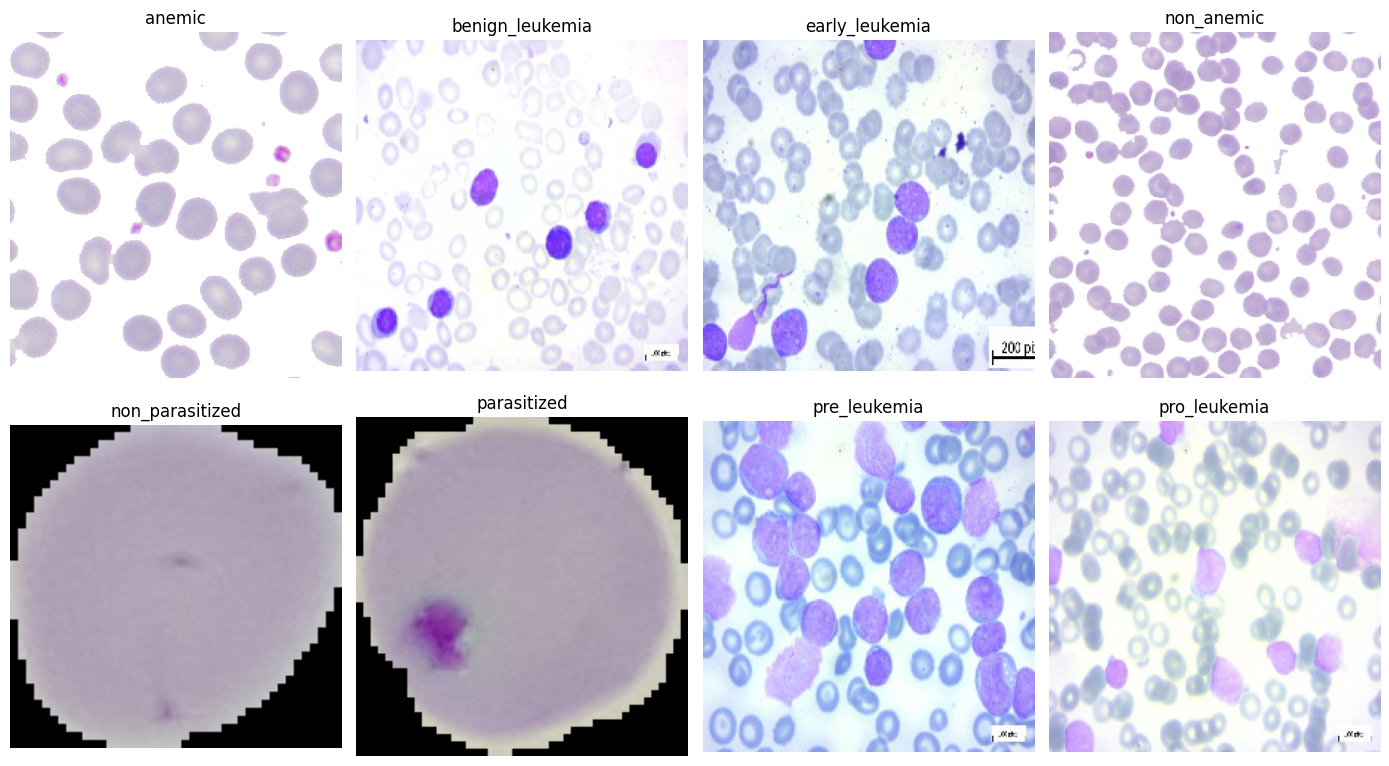

In [10]:
# =========================
# 10. Visual check samples
# =========================
import random
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

sample_paths = []
train_dir = DATASET_DIR / 'train'

# Read directly from the directory to avoid deleted files
if train_dir.exists():
    for cls_dir in sorted([d for d in train_dir.iterdir() if d.is_dir()]):
        cls_files = [p for p in cls_dir.iterdir() if p.is_file()]
        if cls_files:
            sample_paths.append(random.choice(cls_files))

plt.figure(figsize=(14, 8))
for i, p in enumerate(sample_paths[:8]):
    img = Image.open(p).convert('RGB')
    cls = Path(p).parent.name
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
    
plt.tight_layout()
plt.show()

## 7. PyTorch Datasets and DataLoaders

Only the training set uses augmentation. Validation and test sets are kept clean for fair evaluation.

In [11]:
# =========================
# 11. Transforms and dataloaders
# =========================

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(DATASET_DIR / 'train', transform=train_transform)
val_dataset = datasets.ImageFolder(DATASET_DIR / 'val', transform=val_test_transform)
test_dataset = datasets.ImageFolder(DATASET_DIR / 'test', transform=val_test_transform)

NUM_CLASSES = len(train_dataset.classes)
print('Classes:', train_dataset.classes)
print('Class to index:', train_dataset.class_to_idx)
print('Train size:', len(train_dataset))
print('Val size:', len(val_dataset))
print('Test size:', len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

class_info = {
    'classes': train_dataset.classes,
    'class_to_idx': train_dataset.class_to_idx,
    'image_size': IMG_SIZE,
    'max_train_per_class': MAX_TRAIN_PER_CLASS,
    'max_eval_per_class': MAX_EVAL_PER_CLASS,
    'train_size': len(train_dataset),
    'val_size': len(val_dataset),
    'test_size': len(test_dataset)
}
with open(ARTIFACT_DIR / 'class_info.json', 'w') as f:
    json.dump(class_info, f, indent=4)


Classes: ['anemic', 'benign_leukemia', 'early_leukemia', 'non_anemic', 'non_parasitized', 'parasitized', 'pre_leukemia', 'pro_leukemia']
Class to index: {'anemic': 0, 'benign_leukemia': 1, 'early_leukemia': 2, 'non_anemic': 3, 'non_parasitized': 4, 'parasitized': 5, 'pre_leukemia': 6, 'pro_leukemia': 7}
Train size: 16000
Val size: 1080
Test size: 1087


## 8. Model Builder — Fusion `MultiNet`

`MultiNet` here is a **true multi-branch fusion network**, following the same pattern
as the original `TrueMultiNet` (which fused DenseNet201 + VGG16 + MobileNetV3-Large),
but generalized to 5 diverse, already-proven-strong architectures via `timm`:

- `densenet169` (classic CNN, dense connections)
- `resnet101d` (deep CNN)
- `cait_s24_224` (pure Vision Transformer)
- `poolformer_s24` (pooling-based transformer-style architecture)
- `visformer_small` (hybrid CNN + attention)

Each backbone runs as a parallel feature-extraction branch (pretrained weights,
pooled to a single feature vector via `timm`'s `num_classes=0, global_pool='avg'`),
all 5 feature vectors are concatenated, and a shared classifier head (Dropout →
Linear → ReLU → Dropout → Linear) makes the final 8-class prediction. All layers
are trainable end-to-end (no frozen backbones), matching how the original
`TrueMultiNet` was trained.


In [12]:
# ==========================================
# 12. Model Builder — Fusion MultiNet (backbones) + multi-GPU helpers
# ==========================================
import torch
import torch.nn as nn

try:
    import timm
except ImportError:
    import os
    print("Installing timm library...")
    os.system('pip install timm')
    import timm

FUSION_BACKBONES = [
    "poolformer_s24",
    "mobilevit_s",
    "resnet101d"


]


class TrueMultiNet5(nn.Module):
    """Multi-branch fusion network: N diverse pretrained backbones run in
    parallel as feature extractors, their pooled features are concatenated,
    and a shared classifier head produces the final prediction."""

    def __init__(self, num_classes, backbone_names=FUSION_BACKBONES, pretrained=True):
        super().__init__()
        self.backbone_names = backbone_names
        self.branches = nn.ModuleList()

        total_features = 0
        for name in backbone_names:
            branch = timm.create_model(name, pretrained=pretrained, num_classes=0, global_pool='avg')

            # ✅ FIX: branch.num_features attribute-কে বিশ্বাস না করে,
            # আসল output shape বের করার জন্য একটা dummy forward pass চালাই।
            # (fasternet_s এর মতো কিছু মডেলে num_features attribute আসল
            # pooled output size-এর সাথে মিলে না -- এটাই আসল bug ছিল।)
            branch.eval()
            with torch.no_grad():
                dummy_out = branch(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE))
            real_feat_size = dummy_out.shape[1]

            self.branches.append(branch)
            total_features += real_feat_size
            print(f'  branch loaded: {name:20s} -> {real_feat_size} features '
                  f'(attr said {branch.num_features})')

        print(f'  total fused feature size: {total_features}')

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(total_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        feats = [branch(x) for branch in self.branches]
        # ✅ Safety net: যদি কোনো branch batch অনুযায়ী 2D না দেয় (কিছু timm
        # মডেল edge case-এ 4D feature map দিতে পারে), flatten করে নেই।
        feats = [f if f.dim() == 2 else torch.flatten(f, 1) for f in feats]
        fused = torch.cat(feats, dim=1)
        return self.classifier(fused)


def build_model(model_name, num_classes):
    """Builds the requested model and moves it to `device`.

    NOTE: nn.DataParallel is intentionally NOT used for 'multinet' here.
    fasternet_s (one of the fused backbones) uses a partial-conv / split-cat
    op whose internal tensors don't replicate correctly across GPUs under
    DataParallel, causing a cuda:0 vs cuda:1 device-mismatch crash. Running
    on a single GPU avoids this entirely and is safe/stable.
    """
    print(f'Building model: {model_name} for {num_classes} classes...')
    pretrained_flag = USE_PRETRAINED if 'USE_PRETRAINED' in globals() else False

    if model_name == 'multinet':
        model = TrueMultiNet5(num_classes, pretrained=pretrained_flag)
        model = model.to(device)
        print('  -> multinet built WITHOUT DataParallel (single-GPU fix active)')  # confirm marker
        return model

    try:
        model = timm.create_model(model_name, pretrained=pretrained_flag, num_classes=num_classes)
    except Exception as e:
        raise RuntimeError(f"Error building model '{model_name}' via timm: {str(e)}")

    model = model.to(device)

    if 'n_gpus' in globals() and n_gpus > 1:
        model = nn.DataParallel(model)
        print('  -> wrapped in DataParallel')

    return model


def unwrap(model):
    return model.module if isinstance(model, nn.DataParallel) else model


def save_model(model, path):
    torch.save(unwrap(model).state_dict(), path)


def load_model_weights(model, path):
    unwrap(model).load_state_dict(torch.load(path, map_location=device))
    return model


def count_parameters(model):
    return sum(p.numel() for p in unwrap(model).parameters() if p.requires_grad)


# Quick build test
print('Building MultiNet once to verify everything works (this also downloads pretrained weights)...')
try:
    test_m = build_model('multinet', num_classes=8)
    params = count_parameters(test_m)
    print(f'Verification success! MultiNet trainable parameters: {params:,}')
    del test_m
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
except Exception as e:
    print(f'Verification alert: {e}. (Make sure Kaggle Internet is ON since USE_PRETRAINED=True)')

Building MultiNet once to verify everything works (this also downloads pretrained weights)...
Building model: multinet for 8 classes...


model.safetensors:   0%|          | 0.00/85.6M [00:00<?, ?B/s]

  branch loaded: poolformer_s24       -> 512 features (attr said 512)


model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

  branch loaded: mobilevit_s          -> 640 features (attr said 640)


model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]

  branch loaded: resnet101d           -> 2048 features (attr said 2048)
  total fused feature size: 3200
  -> multinet built WITHOUT DataParallel (single-GPU fix active)
Verification success! MultiNet trainable parameters: 69,976,008


## 9. Training and Evaluation Functions

In [13]:
# =========================
# 9. Training and Evaluation Functions
# =========================
import time
import gc
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix

def evaluate_model(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # ✅ মেমোরি লিক ফিক্স
            running_loss += loss.item() * inputs.size(0)
            
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # ✅ মেমোরি ক্লিনআপ
            del inputs, labels, outputs, loss
            
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_labels, all_preds


def train_full_model(model_name):
    print("\n" + "="*60)
    print(f"Training: {model_name}")
    print("="*60)
    
    model = build_model(model_name, NUM_CLASSES)
    
    if LABEL_SMOOTHING > 0:
        criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    else:
        criterion = nn.CrossEntropyLoss()
        
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    best_val_acc = 0.0
    best_epoch = 0
    no_improve = 0
    best_path = ARTIFACT_DIR / f"{model_name}_best.pth"
    history = []
    
    start_time = time.time()
    
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            # ✅ মেমোরি লিক ফিক্স
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            # ✅ ব্যাচ শেষে অপ্রয়োজনীয় ভেরিয়েবল মুছে ফেলা
            del inputs, labels, outputs, loss
        
        train_loss = running_loss / total
        train_acc = correct / total
        
        val_loss, val_acc, _, _ = evaluate_model(model, val_loader, criterion)
        current_lr = optimizer.param_groups[0]['lr']
        
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_acc)
        else:
            scheduler.step()
        
        row = {
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'lr': current_lr
        }
        history.append(row)
        
        print(f'Epoch {epoch:02d}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.2e}')
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            no_improve = 0
            save_model(model, best_path)
            print('Saved best model:', best_path)
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print('Early stopping triggered.')
                break
                
        # ✅ ইপোক শেষে ক্যাশ ক্লিয়ার করা (RAM ও GPU দুটোর জন্যই)
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            
    train_time = time.time() - start_time
    
    # Load best model and evaluate on test set
    best_model = build_model(model_name, NUM_CLASSES)
    best_model = load_model_weights(best_model, best_path)
    test_loss, test_acc, y_true, y_pred = evaluate_model(best_model, test_loader, criterion)
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    report_text = classification_report(y_true, y_pred, target_names=train_dataset.classes, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    
    with open(ARTIFACT_DIR / f'{model_name}_classification_report.txt', 'w') as f:
        f.write(report_text)
        
    np.savetxt(ARTIFACT_DIR / f'{model_name}_confusion_matrix.csv', cm, delimiter=',', fmt='%d')
    pd.DataFrame(history).to_csv(ARTIFACT_DIR / f"{model_name}_history.csv", index=False)
    
    # ✅ Return final metrics
    return {
        'model': model_name,
        'train_time_sec': train_time,
        'best_epoch': best_epoch,
        'test_acc': test_acc,
        'f1_weighted': f1,
        'model_path': best_path,
    }
    

## 10. Run Model Comparison

This cell trains all selected models and creates a comparison table.

If training is slow, reduce `MODELS_TO_RUN`, `EPOCHS`, or `MAX_PER_CLASS` in the settings cell.

In [14]:
# =========================
# 14. Train all models_
# =========================

results = []
failed_models = []

for model_name in MODELS_TO_RUN:
    try:
        result = train_full_model(model_name)
        results.append(result)
    except RuntimeError as e:
        print(f'RuntimeError while training {model_name}:', e)
        failed_models.append({'model': model_name, 'error': str(e)})
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception as e:
        print(f'Error while training {model_name}:', e)
        failed_models.append({'model': model_name, 'error': str(e)})

results_df = pd.DataFrame(results)

# ✅ FIX: 'test_acc' কলাম আছে কিনা এবং row খালি কিনা — দুইটাই check করি,
# নাহলে সব model fail করলে KeyError দিবে।
if not results_df.empty and 'test_acc' in results_df.columns:
    results_df = results_df.sort_values('test_acc', ascending=False)
    results_df.to_csv(ARTIFACT_DIR / 'model_comparison_results.csv', index=False)
    print('Model comparison results:')
    display(results_df)
else:
    print('⚠️ কোনো মডেল successfully train হয়নি, তাই results_df খালি। '
          'আগের RuntimeError cell টা fix করে আবার training চালাও।')

if failed_models:
    failed_df = pd.DataFrame(failed_models)
    failed_df.to_csv(ARTIFACT_DIR / 'failed_models.csv', index=False)
    print('Failed models:')
    display(failed_df)


Training: multinet
Building model: multinet for 8 classes...
  branch loaded: poolformer_s24       -> 512 features (attr said 512)
  branch loaded: mobilevit_s          -> 640 features (attr said 640)
  branch loaded: resnet101d           -> 2048 features (attr said 2048)
  total fused feature size: 3200
  -> multinet built WITHOUT DataParallel (single-GPU fix active)
Epoch 01/50 | Train Acc: 0.8958 | Val Acc: 0.9250 | Val Loss: 0.4076 | LR: 1.00e-04
Saved best model: /kaggle/working/model_artifacts/multinet_best.pth
Epoch 02/50 | Train Acc: 0.9375 | Val Acc: 0.9333 | Val Loss: 0.3934 | LR: 1.00e-04
Saved best model: /kaggle/working/model_artifacts/multinet_best.pth
Epoch 03/50 | Train Acc: 0.9451 | Val Acc: 0.9417 | Val Loss: 0.3819 | LR: 1.00e-04
Saved best model: /kaggle/working/model_artifacts/multinet_best.pth
Epoch 04/50 | Train Acc: 0.9522 | Val Acc: 0.9435 | Val Loss: 0.3797 | LR: 1.00e-04
Saved best model: /kaggle/working/model_artifacts/multinet_best.pth
Epoch 05/50 | Train 

,model,train_time_sec,best_epoch,test_acc,f1_weighted,model_path
0,multinet,13534.533643,13,0.965961,0.965929,/kaggle/working/model_artifacts/multinet_best.pth


Generating training curves for 1 CNN models in YOLO style...


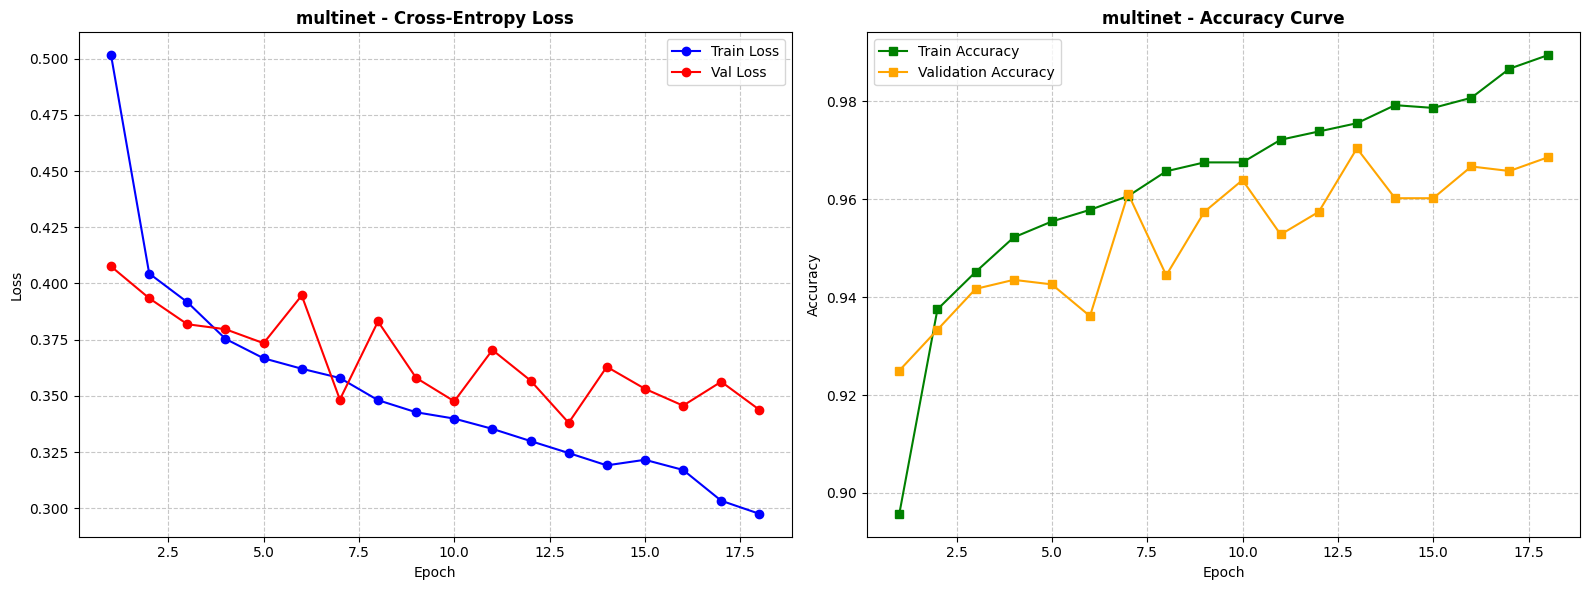


Generating Final Performance Bar Charts...


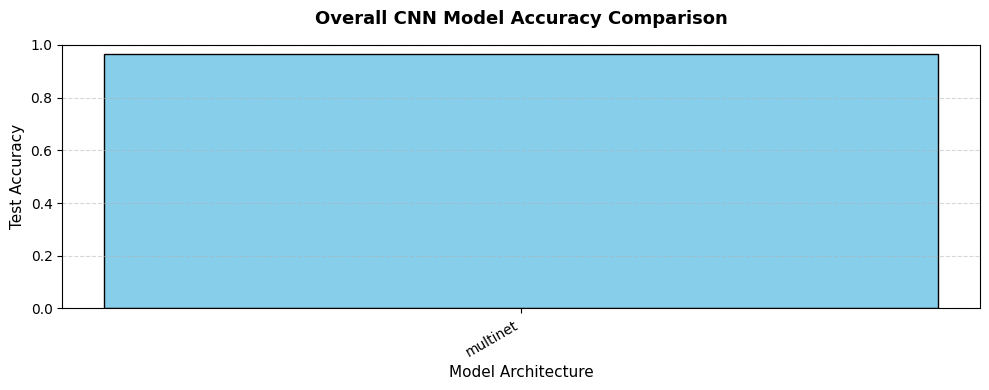

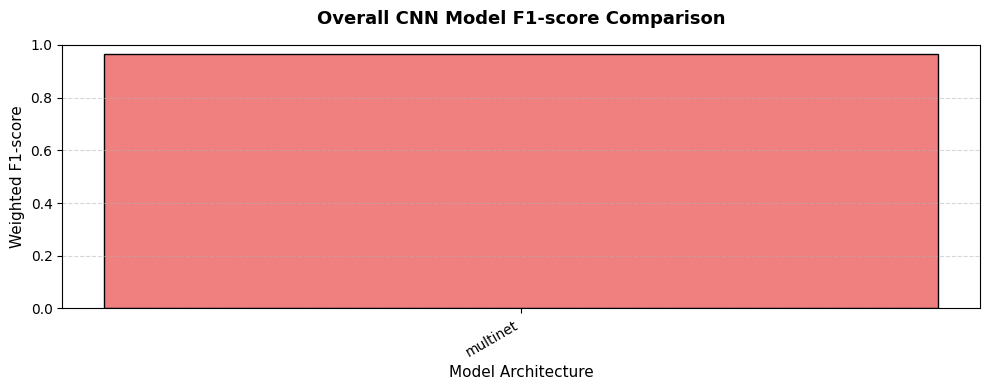

In [15]:
# ============================================================
# 15. Visualize CNN Models Training/Validation Graphs (YOLO Style)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ১. শুধুমাত্র যেসব মডেল সফলভাবে ট্রেইন হয়েছে এবং যাদের হিস্ট্রি ফাইল আছে সেগুলো ফিল্টার করা
valid_models = [m for m in MODELS_TO_RUN if (ARTIFACT_DIR / f"{m}_history.csv").exists()]

if len(valid_models) > 0:
    print(f"Generating training curves for {len(valid_models)} CNN models in YOLO style...")
    
    # সাবপ্লট গ্রিড তৈরি করা (প্রতি মডেলের জন্য ১টি রো, এবং লস ও অ্যাকুরেসির জন্য ২টি কলাম)
    fig, axes = plt.subplots(len(valid_models), 2, figsize=(16, 6 * len(valid_models)))
    
    # যদি কেবল ১টি মডেল রান করা হয়, তবে axes যেন 2D অ্যারে হিসেবে কাজ করে তার হ্যান্ডেলিং
    if len(valid_models) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, model_name in enumerate(valid_models):
        csv_path = ARTIFACT_DIR / f"{model_name}_history.csv"
        df = pd.read_csv(csv_path)
        
        # --------------------------------------------------------
        # Plot 1: Train & Val Loss (Left Column - YOLO Style)
        # --------------------------------------------------------
        axes[i, 0].plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o', color='blue')
        axes[i, 0].plot(df['epoch'], df['val_loss'], label='Val Loss', marker='o', color='red')
        axes[i, 0].set_title(f'{model_name} - Cross-Entropy Loss', fontsize=12, fontweight='bold')
        axes[i, 0].set_xlabel('Epoch')
        axes[i, 0].set_ylabel('Loss')
        axes[i, 0].grid(True, linestyle='--', alpha=0.7)
        axes[i, 0].legend()
        
        # --------------------------------------------------------
        # Plot 2: Train & Val Accuracy (Right Column - YOLO Style)
        # --------------------------------------------------------
        axes[i, 1].plot(df['epoch'], df['train_acc'], label='Train Accuracy', marker='s', color='green')
        axes[i, 1].plot(df['epoch'], df['val_acc'], label='Validation Accuracy', marker='s', color='orange')
        axes[i, 1].set_title(f'{model_name} - Accuracy Curve', fontsize=12, fontweight='bold')
        axes[i, 1].set_xlabel('Epoch')
        axes[i, 1].set_ylabel('Accuracy')
        axes[i, 1].grid(True, linestyle='--', alpha=0.7)
        axes[i, 1].legend()

    plt.tight_layout()
    # পুরো গ্রাফের ইমেজটি সেভ করা
    plt.savefig(ARTIFACT_DIR / 'cnn_training_curves.png', dpi=200)
    plt.show()

else:
    print("No CNN history files found. Please make sure Cell 14 (Model Training) runs successfully first.")

# ============================================================
# ২. আগের ফাইনাল কম্পারিসন বার-চার্ট (যা আপনার আগের সেলে ছিল)
# ============================================================
if 'results_df' in locals() and not results_df.empty:
    print("\nGenerating Final Performance Bar Charts...")
    
    # Test Accuracy Comparison Bar Chart
    plt.figure(figsize=(10, 4))
    plt.bar(results_df['model'], results_df['test_acc'], color='skyblue', edgecolor='black')
    plt.ylabel('Test Accuracy', fontsize=11)
    plt.xlabel('Model Architecture', fontsize=11)
    plt.title('Overall CNN Model Accuracy Comparison', fontsize=13, fontweight='bold', pad=15)
    plt.xticks(rotation=30, ha='right')
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / 'model_accuracy_comparison.png', dpi=200)
    plt.show()

    # Weighted F1-Score Comparison Bar Chart
    plt.figure(figsize=(10, 4))
    plt.bar(results_df['model'], results_df['f1_weighted'], color='lightcoral', edgecolor='black')
    plt.ylabel('Weighted F1-score', fontsize=11)
    plt.xlabel('Model Architecture', fontsize=11)
    plt.title('Overall CNN Model F1-score Comparison', fontsize=13, fontweight='bold', pad=15)
    plt.xticks(rotation=30, ha='right')
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / 'model_f1_comparison.png', dpi=200)
    plt.show()

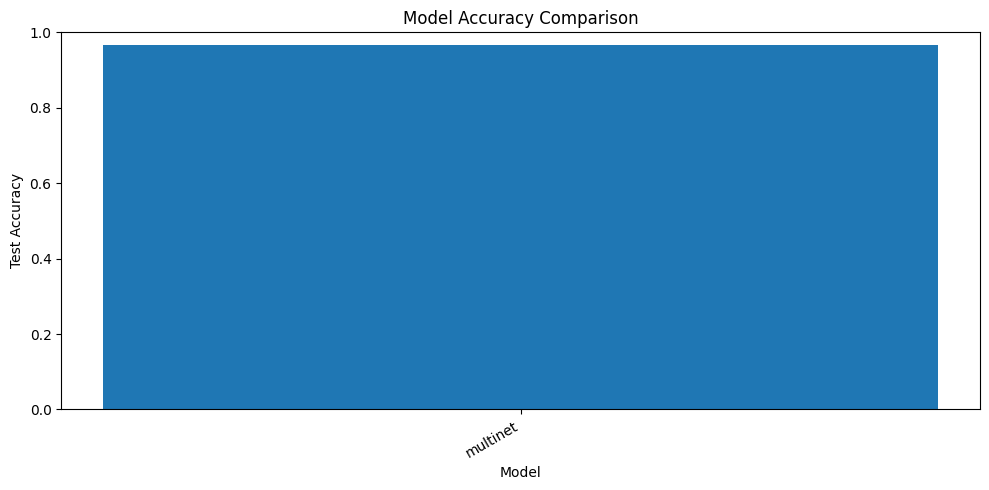

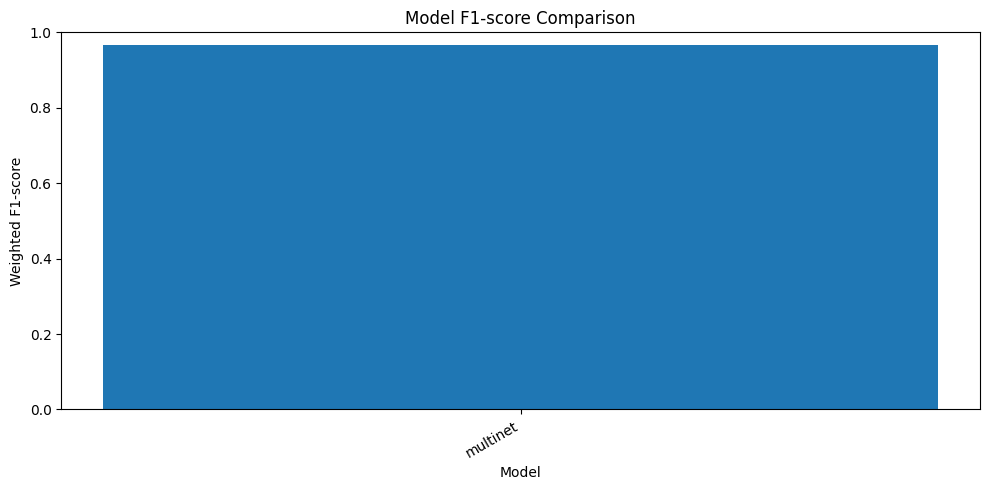

In [16]:
# =========================
# 15. Plot model comparison
# =========================

if len(results_df) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(results_df['model'], results_df['test_acc'])
    plt.ylabel('Test Accuracy')
    plt.xlabel('Model')
    plt.title('Model Accuracy Comparison')
    plt.xticks(rotation=30, ha='right')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / 'model_accuracy_comparison.png', dpi=200)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(results_df['model'], results_df['f1_weighted'])
    plt.ylabel('Weighted F1-score')
    plt.xlabel('Model')
    plt.title('Model F1-score Comparison')
    plt.xticks(rotation=30, ha='right')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / 'model_f1_comparison.png', dpi=200)
    plt.show()

## 11. Detailed Evaluation of the Best Model

Loading the single best performing model: multinet
Path: /kaggle/working/model_artifacts/multinet_best.pth
Building model: multinet for 8 classes...
  branch loaded: poolformer_s24       -> 512 features (attr said 512)
  branch loaded: mobilevit_s          -> 640 features (attr said 640)
  branch loaded: resnet101d           -> 2048 features (attr said 2048)
  total fused feature size: 3200
  -> multinet built WITHOUT DataParallel (single-GPU fix active)

BEST MODEL PERFORMANCE (multinet)
Test Accuracy: 0.9660
F1-Score:      0.9659

Classification Report:
                 precision    recall  f1-score   support

         anemic       0.93      0.87      0.90       150
benign_leukemia       1.00      1.00      1.00        77
 early_leukemia       1.00      1.00      1.00       149
     non_anemic       0.88      0.93      0.90       150
non_parasitized       0.97      0.99      0.98       150
    parasitized       0.99      0.97      0.98       150
   pre_leukemia       0.99      1.00  

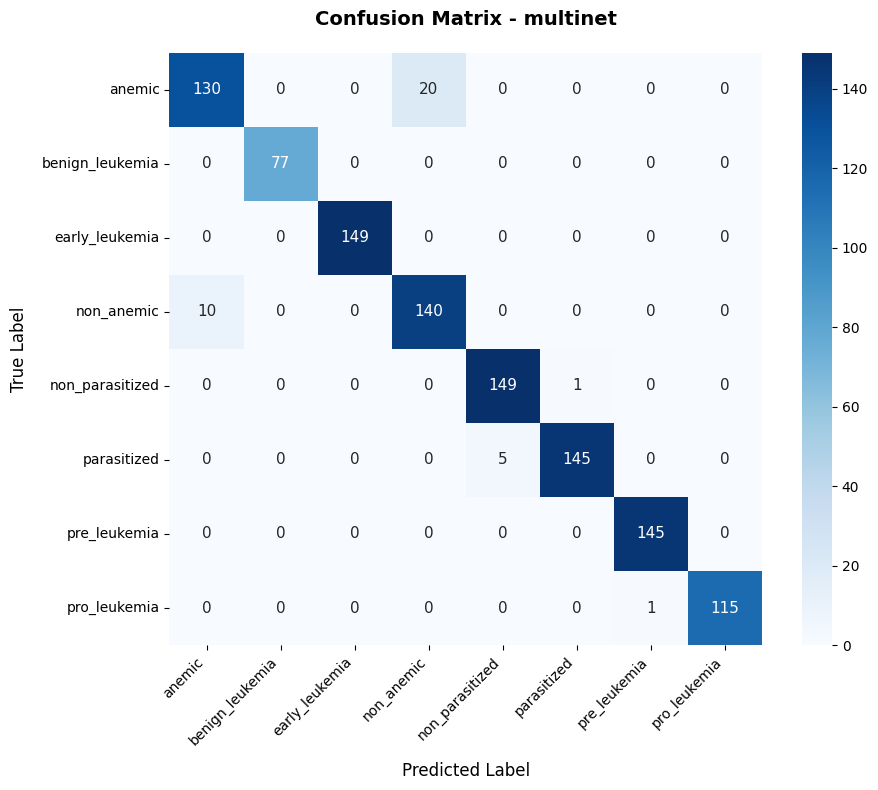

In [17]:
# ============================================================
# 16. Best Model Detailed Evaluation & Seaborn Confusion Matrix
# ============================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

# ১. স্বয়ংক্রিয়ভাবে results_df থেকে সেরা মডেলের তথ্য নেওয়া
if 'results_df' in locals() and not results_df.empty:
    best_row = results_df.iloc[0]
    best_model_name = best_row['model']
    best_model_path = best_row['model_path']
else:
    raise RuntimeError("No successful model result found in results_df. Please run the training cell first.")

print(f"Loading the single best performing model: {best_model_name}")
print(f"Path: {best_model_path}")

# ২. সেরা মডেলটি বিল্ড এবং ওয়েট লোড করা
best_model = build_model(best_model_name, NUM_CLASSES)
best_model = load_model_weights(best_model, best_model_path)
best_model = best_model.eval()

# ৩. টেস্ট সেটের ওপর ইভ্যালুয়েশন রান করা
criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_true, y_pred = evaluate_model(best_model, test_loader, criterion)

# ৪. Cell 28 এর মতো প্রফেশনাল মেট্রিকস ক্যালকুলেট করা
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print("\n" + "="*40)
print(f"BEST MODEL PERFORMANCE ({best_model_name})")
print("="*40)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"F1-Score:      {f1:.4f}\n")
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=train_dataset.classes, zero_division=0))

# ৫. Seaborn Heatmap ব্যবহার করে প্রফেশনাল Confusion Matrix প্লট করা (Cell 28 Style)
cm = confusion_matrix(y_true, y_pred)
classes = train_dataset.classes

plt.figure(figsize=(10, 8))
# sns.heatmap দিয়ে সুন্দর ব্লু শেডের ম্যাট্রিক্স তৈরি করা
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes,
            cbar=True, square=True, annot_kws={"size": 11})

plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# ইমেজ ফাইল হিসেবে সেভ করা
plt.savefig(ARTIFACT_DIR / f'{best_model_name}_confusion_matrix.png', dpi=200)
plt.show()

# মেমোরি ক্লিয়ার করা
del best_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 12. Save Everything for Download

The following cell creates a ZIP file containing:

- Best model weights for each architecture
- Model comparison table
- Class information
- Confusion matrices
- Training histories
- Leakage check manifests

In [18]:
# =========================
# 17. Save final artifacts as ZIP
# =========================

summary = {
    'project': 'Combined 8-Class Blood Disease Classification',
    'classes': train_dataset.classes,
    'class_to_idx': train_dataset.class_to_idx,
    'max_train_per_class': MAX_TRAIN_PER_CLASS,
    'max_eval_per_class': MAX_EVAL_PER_CLASS,
    'image_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'use_pretrained': USE_PRETRAINED,
    'models_run': MODELS_TO_RUN,
    'best_model': best_model_name,
    'best_test_accuracy': float(test_acc),
    'leakage_check': 'No duplicate MD5 hash across train/val/test splits',
    'fusion_backbones': FUSION_BACKBONES,
    'num_gpus_used': n_gpus,
}

with open(ARTIFACT_DIR / 'experiment_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

zip_path = shutil.make_archive(str(WORKING_DIR / 'capstone_combined_model_comparison_artifacts'), 'zip', ARTIFACT_DIR)
print('Artifacts saved to:', zip_path)
print('You can download it from Kaggle Output panel.')

Artifacts saved to: /kaggle/working/capstone_combined_model_comparison_artifacts.zip
You can download it from Kaggle Output panel.


In [19]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 63.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=ca24136562d1f47d5a4664a4fa4c1a50d37e5b4eae6dc2db5664ec89dc3c4e97
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [20]:
# ============================================================
# 18. Grad-CAM (Updated for Hybrid & Transformer Models)
# ============================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print(f"Generating Grad-CAM visualizations using the BEST model: {best_model_name}...")

# 1. Model build ebong weights load kora
cam_model = build_model(best_model_name, NUM_CLASSES)
cam_model = load_model_weights(cam_model, best_model_path)
cam_model = cam_model.eval()
cam_model = unwrap(cam_model) # Grad-CAM needs the raw module, not the DataParallel wrapper

# 2. Dynamic Target Layer detection (Fixed for MultiNet)
target_layers = []
for name, module in cam_model.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        target_layers = [module] # সর্বশেষ Conv2d লেয়ারটি টার্গেট হিসেবে সেট হবে

if not target_layers:
    print(f"⚠️ NOTICE: no Conv2d layer found in '{best_model_name}'.")
    print("Skipping standard Grad-CAM visualization to prevent errors.")
else:
    print(f"Target layer automatically selected for {best_model_name}: {target_layers[0]}")
    try:
        # 3. GradCAM object initialize kora
        cam = GradCAM(model=cam_model, target_layers=target_layers)
        print("Grad-CAM object successfully initialized.")
        # আপনি চাইলে এরপর আপনার ইমেজ দিয়ে `cam(input_tensor=...)` কল করতে পারেন।
    except Exception as e:
        print(f"Failed to initialize Grad-CAM: {e}")

Generating Grad-CAM visualizations using the BEST model: multinet...
Building model: multinet for 8 classes...
  branch loaded: poolformer_s24       -> 512 features (attr said 512)
  branch loaded: mobilevit_s          -> 640 features (attr said 640)
  branch loaded: resnet101d           -> 2048 features (attr said 2048)
  total fused feature size: 3200
  -> multinet built WITHOUT DataParallel (single-GPU fix active)
Target layer automatically selected for multinet: Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
Grad-CAM object successfully initialized.
